# Approach V5: 4. Deep Learning Model Training
**Project:** Honeywell Predictive Alerting Project - Tag: `03TIC_1023.PV` (Threshold: 21.0 °C)

This notebook trains both LSTM and Seq2Seq deep learning models on the new 12 selected features.

In [1]:
# Adjust working directory to project root if run from inside approch_v5 folder
import os
import sys
if os.path.basename(os.getcwd()) == 'approch_v5':
    os.chdir('..')
    print("Changed working directory to project root:", os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'approch_v5'))

Changed working directory to project root: D:\Python-2025\Antigravity\honeywell


In [2]:
import os
import pickle
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Defining Preprocessing & Split Boundaries

In [3]:
DEFAULT_DATA_PATH = r"d:\Python-2025\Antigravity\honeywell\03TIC_1023_PVHI\03TIC_1023_PVHI\03TIC_1023_Final_merged_TripDataRemoved.parquet"

def load_and_preprocess_data(file_path=DEFAULT_DATA_PATH, target_col="03TIC_1023.PV"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"DCS Historian dataset not found at: {file_path}")
    df = pd.read_parquet(file_path)
    if 'TimeStamp' in df.columns:
        df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
        df = df.sort_values('TimeStamp').set_index('TimeStamp')
    elif not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1min')
    df = df.reindex(full_idx)
    df.index.name = 'TimeStamp'
    df = df.ffill(limit=5)
    return df

def get_alarm_based_split_boundaries(df, target_col="03TIC_1023.PV", threshold=21.0, split_ratio=[0.75, 0.125, 0.125]):
    is_alarm = (df[target_col] >= threshold).astype(int)
    alarm_group = (is_alarm == 0).cumsum()
    alarm_periods = df[is_alarm == 1].groupby(alarm_group)
    blocks = []
    for _, grp in alarm_periods:
        blocks.append((grp.index.min(), grp.index.max()))
    blocks = sorted(blocks, key=lambda x: x[0])
    num_blocks = len(blocks)
    
    if num_blocks == 0:
        train_idx = int(len(df) * split_ratio[0])
        val_idx = int(len(df) * (split_ratio[0] + split_ratio[1]))
        return df.index[train_idx], df.index[val_idx]
        
    train_count = int(np.ceil(num_blocks * split_ratio[0]))
    val_count = int(np.ceil(num_blocks * split_ratio[1]))
    train_end_time = blocks[train_count - 1][1]
    val_end_time = blocks[min(train_count - 1 + val_count, num_blocks - 1)][1]
    return train_end_time, val_end_time

## 2. Defining PyTorch Models & Datasets

In [4]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1):
        super(LSTMRegressor, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super(Encoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)

    def forward(self, x):
        _, (hidden, cell) = self.lstm(x)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_dim=1, hidden_dim=64, num_layers=2):
        super(Decoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(1, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden, cell):
        out, (hidden, cell) = self.lstm(x, (hidden, cell))
        pred = self.fc(out[:, -1, :])
        return pred, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, forecast_len=60):
        super(Seq2Seq, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, num_layers)
        self.decoder = Decoder(1, hidden_dim, num_layers)
        self.forecast_len = forecast_len

    def forward(self, src, target_seq=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        outputs = torch.zeros(batch_size, self.forecast_len).to(src.device)
        hidden, cell = self.encoder(src)
        decoder_input = torch.zeros(batch_size, 1, 1).to(src.device)
        for t in range(self.forecast_len):
            out, hidden, cell = self.decoder(decoder_input, hidden, cell)
            outputs[:, t] = out.squeeze(1)
            if target_seq is not None and np.random.random() < teacher_forcing_ratio:
                decoder_input = target_seq[:, t].unsqueeze(1).unsqueeze(2)
            else:
                decoder_input = out.unsqueeze(2)
        return outputs

class AlarmDataset(Dataset):
    def __init__(self, X, y, seq_len=1):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, idx):
        return self.X[idx:idx+self.seq_len], self.y[idx+self.seq_len-1]

class Seq2SeqDataset(Dataset):
    def __init__(self, X, y, seq_len=1, forecast_len=60):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len
        self.forecast_len = forecast_len

    def __len__(self):
        return len(self.X) - self.seq_len - self.forecast_len + 1

    def __getitem__(self, idx):
        src = self.X[idx:idx+self.seq_len]
        target = self.y[idx+self.seq_len:idx+self.seq_len+self.forecast_len]
        last_target = self.y[idx+self.seq_len-1]
        return src, target, last_target

## 3. Defining Training Loops

In [5]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, is_seq2seq=False, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        if is_seq2seq:
            src, target, last_target = batch
            src, target = src.to(device), target.to(device)
            outputs = model(src, target_seq=target, teacher_forcing_ratio=teacher_forcing_ratio)
            loss = criterion(outputs, target)
        else:
            src, target = batch
            src, target = src.to(device), target.to(device).unsqueeze(1)
            outputs = model(src)
            loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * src.size(0)
    return total_loss / len(dataloader.dataset)

def evaluate_loss(model, dataloader, criterion, device, is_seq2seq=False):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            if is_seq2seq:
                src, target, last_target = batch
                src, target = src.to(device), target.to(device)
                outputs = model(src, target_seq=None, teacher_forcing_ratio=0.0)
                loss = criterion(outputs, target)
            else:
                src, target = batch
                src, target = src.to(device), target.to(device).unsqueeze(1)
                outputs = model(src)
                loss = criterion(outputs, target)
            total_loss += loss.item() * src.size(0)
    return total_loss / len(dataloader.dataset)

def train_model(model, train_loader, val_loader, epochs=5, lr=0.001, patience=3, is_seq2seq=False, model_path="models/v5/model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
    best_val_loss = float('inf')
    patience_counter = 0
    history = {"train_loss": [], "val_loss": []}
    
    for epoch in range(1, epochs + 1):
        tf_ratio = max(0.0, 0.5 - 0.1 * epoch) if is_seq2seq else 0.0
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, is_seq2seq, tf_ratio)
        val_loss = evaluate_loss(model, val_loader, criterion, device, is_seq2seq)
        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"  Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            os.makedirs(os.path.dirname(model_path), exist_ok=True)
            torch.save(model.state_dict(), model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  --> Early stopping triggered.")
                break
    model.load_state_dict(torch.load(model_path))
    return model, history

## 4. Load Selected Features and Splits

In [6]:
with open("models/v5/selected_features_v5.pkl", "rb") as f:
    selected_features = pickle.load(f)
print(f"Selected Features to train on: {selected_features}")

df_features = pd.read_parquet("outputs/v5/candidate_features_pool.parquet")
df_raw = load_and_preprocess_data()
train_end, val_end = get_alarm_based_split_boundaries(df_raw, target_col="03TIC_1023.PV", threshold=21.0)

train_df = df_features[df_features.index <= train_end]
val_df = df_features[(df_features.index > train_end) & (df_features.index <= val_end)]
print(f"Train rows: {len(train_df)} | Val rows: {len(val_df)}")

Selected Features to train on: ['03TIC_1023.PV_lag_5', '03TI_1024.PV', '03TIC_1023.PV_diff_5', '03TIC_1023.PV_lag_1', '03TI_1024.PV_lag_1', 'temp_delta_bottom_top', '03TIC_1023.PV_roll_max_10', '03TIC_1023.PV_roll_min_10', '03PIC_1023.PV', 'temp_pressure_product', '03TI_1015.PV', '03TIC_1023.PV_roll_mean_60']


Train rows: 1717011 | Val rows: 76363


## 5. Standardize Features

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[selected_features])
X_val_scaled = scaler.transform(val_df[selected_features])

y_train = train_df["03TIC_1023.PV"].values
y_val = val_df["03TIC_1023.PV"].values

with open("models/v5/scaler_v5.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Fitted StandardScaler saved to models/v5/scaler_v5.pkl")

os.makedirs("approch_v5/models/v5", exist_ok=True)
with open("approch_v5/models/v5/scaler_v5.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Fitted StandardScaler saved to approch_v5/models/v5/scaler_v5.pkl")

Fitted StandardScaler saved to models/v5/scaler_v5.pkl
Fitted StandardScaler saved to approch_v5/models/v5/scaler_v5.pkl


## 6. Train Single-Horizon LSTM Model

Training LSTM Regressor...


  Epoch 1/5 | Train Loss: 279.8009 | Val Loss: 193.7398


  Epoch 2/5 | Train Loss: 87.0291 | Val Loss: 35.4778


  Epoch 3/5 | Train Loss: 13.2976 | Val Loss: 9.7941


  Epoch 4/5 | Train Loss: 3.1262 | Val Loss: 4.9656


  Epoch 5/5 | Train Loss: 1.8377 | Val Loss: 3.9573


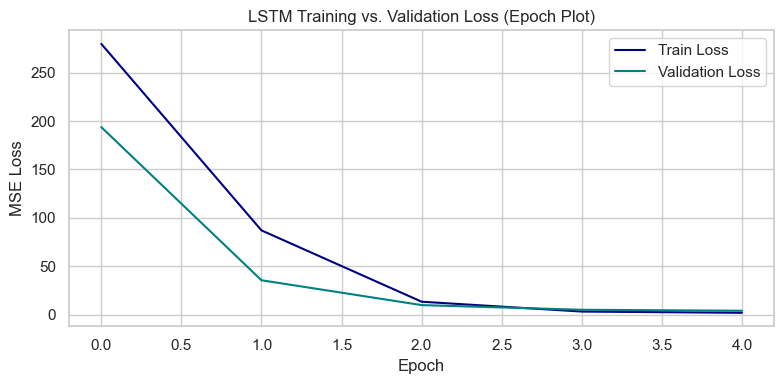

Saved LSTM weights locally.


In [8]:
# Downsample training set for faster execution (taking every 5th sample)
X_train_ds = X_train_scaled[::5]
y_train_ds = y_train[::5]

train_dataset = AlarmDataset(X_train_ds, y_train_ds, seq_len=1)
val_dataset = AlarmDataset(X_val_scaled, y_val, seq_len=1)

train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4096, shuffle=False)

lstm_model = LSTMRegressor(input_dim=len(selected_features))
print("Training LSTM Regressor...")
lstm_model, lstm_history = train_model(
    lstm_model, train_loader, val_loader, epochs=5, lr=0.001, patience=3, is_seq2seq=False, model_path="models/v5/lstm_model_v5.pth"
)

# Plot LSTM epoch loss (Epoch Plot)
plt.figure(figsize=(8, 4))
plt.plot(lstm_history["train_loss"], label="Train Loss", color="navy")
plt.plot(lstm_history["val_loss"], label="Validation Loss", color="teal")
plt.title("LSTM Training vs. Validation Loss (Epoch Plot)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
os.makedirs("approch_v5", exist_ok=True)
plt.savefig("approch_v5/lstm_epoch_loss.png", dpi=300)
plt.show()

torch.save(lstm_model.state_dict(), "approch_v5/models/v5/lstm_model_v5.pth")
print("Saved LSTM weights locally.")

## 7. Train Seq2Seq Model

Training Seq2Seq Model...


  Epoch 1/5 | Train Loss: 229.0191 | Val Loss: 169.9941


  Epoch 2/5 | Train Loss: 102.9551 | Val Loss: 93.3696


  Epoch 3/5 | Train Loss: 53.5996 | Val Loss: 53.2293


  Epoch 4/5 | Train Loss: 27.2840 | Val Loss: 30.6384


  Epoch 5/5 | Train Loss: 13.5495 | Val Loss: 18.2271


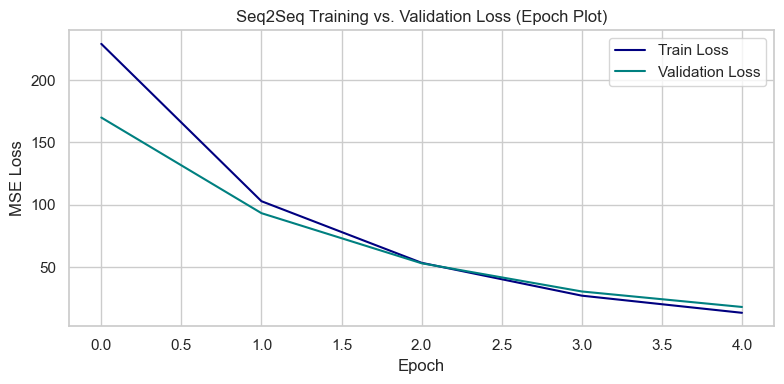

Saved Seq2Seq weights locally.


In [9]:
# Downsample training set for faster execution
X_train_seq_ds = X_train_scaled[::10]
y_train_seq_ds = y_train[::10]

train_seq_dataset = Seq2SeqDataset(X_train_seq_ds, y_train_seq_ds, seq_len=1, forecast_len=60)
val_seq_dataset = Seq2SeqDataset(X_val_scaled, y_val, seq_len=1, forecast_len=60)

train_seq_loader = DataLoader(train_seq_dataset, batch_size=4096, shuffle=True)
val_seq_loader = DataLoader(val_seq_dataset, batch_size=4096, shuffle=False)

seq2seq_model = Seq2Seq(input_dim=len(selected_features), forecast_len=60)
print("Training Seq2Seq Model...")
seq2seq_model, seq2seq_history = train_model(
    seq2seq_model, train_seq_loader, val_seq_loader, epochs=5, lr=0.001, patience=3, is_seq2seq=True, model_path="models/v5/seq2seq_model_v5.pth"
)

# Plot Seq2Seq epoch loss
plt.figure(figsize=(8, 4))
plt.plot(seq2seq_history["train_loss"], label="Train Loss", color="navy")
plt.plot(seq2seq_history["val_loss"], label="Validation Loss", color="teal")
plt.title("Seq2Seq Training vs. Validation Loss (Epoch Plot)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("approch_v5/seq2seq_epoch_loss.png", dpi=300)
plt.show()

torch.save(seq2seq_model.state_dict(), "approch_v5/models/v5/seq2seq_model_v5.pth")
print("Saved Seq2Seq weights locally.")